<a href="https://colab.research.google.com/github/anderson-perez/IAC/blob/main/%C3%81rvores_de_Decis%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inteligência Artificial e Computacional

## Segunda Parte da Disciplina

# Informações:

- Prof. Anderson Luiz Fernandes Perez
- Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
- Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

# Árvores de Decisão


Modelo de aprendizado de máquina que toma decisões com base em perguntas sucessivas. A estrutura de dados que dá suporte a este modelo é uma árvore.


## Estrutura de uma Árvore de Decisão

* Nó raíz - primeiro nó da árvore
* Nó interno - nó que faz uma pergunta
* Aresta - caminho entre dois nós
* Nó folha - resultado final (predição)
* Profundidade - número de níveis de uma árvore

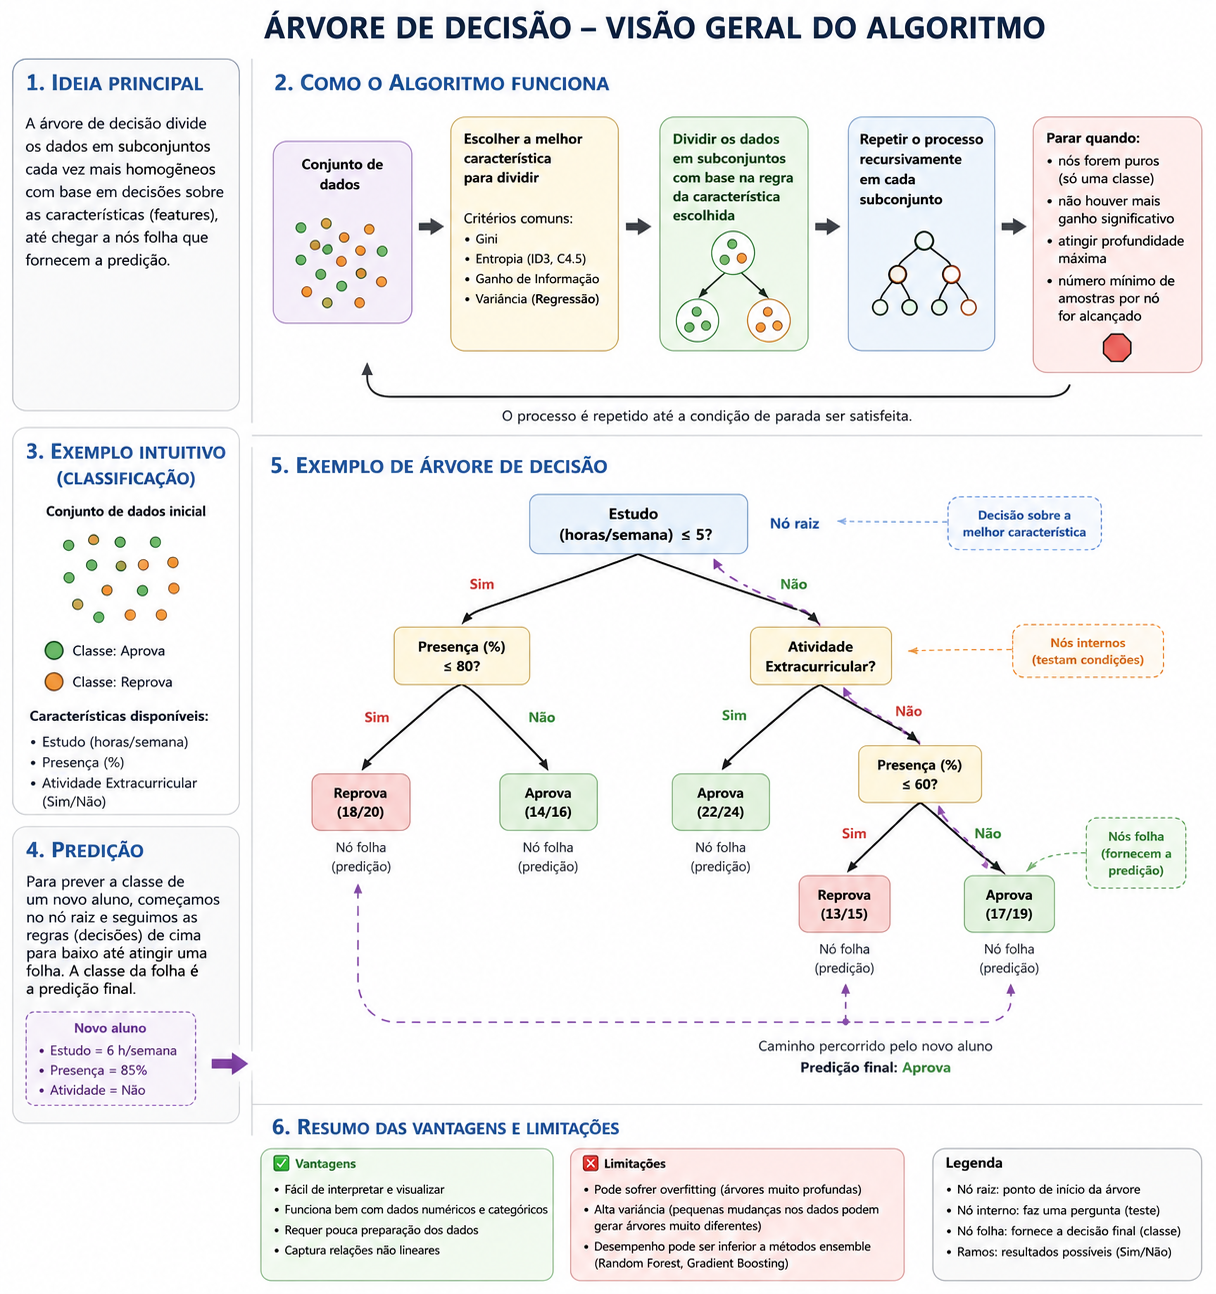

## Classificação


A árvore tenta dividir os dados de forma que os grupos resultantes fiquem mais “puros”.

Em classificação, um grupo puro contém exemplos de uma única classe.

Exemplo:

Grupo impuro:
[Sim, Não, Sim, Não, Sim]

Grupo puro:
[Sim, Sim, Sim, Sim]
Para medir a impureza, os critérios mais comuns são:

* Índice Gini
* Entropia
* Ganho de Informação

## Cálculo do ìndice de Gini

O índice Gini mede o grau de mistura das classes em um nó.

$$ Gini = 1 - \sum_{i=1}^{c} p_i^2$$

onde:

* ($c$) é o número de classes;

* ($p_i$) é a proporção de elementos da classe ($i$).

Se o nó for puro, o Gini será 0.

Exemplo:

Um nó possui 10 amostras:

7 da classe A;
3 da classe B.

$$ Gini = 1 - (0{,}7)^2 - (0{,}3)^2 $$

$$ Gini = 1 - 0{,}49 - 0{,}09 = 0{,}42 $$

In [3]:
# Cálculo do índice Gini (exemplo)

p_A = 7 / 10
p_B = 3 / 10

gini = 1 - p_A**2 - p_B**2

print("Gini =", gini)

Gini = 0.42000000000000004


## Cálculo da Entropia

A entropia também mede impureza.

$$ Entropia = - \sum_{i=1}^{c} p_i \log_2(p_i) $$


Quanto maior a entropia, maior a mistura das classes.

- Entropia = 0: nó puro;
- Entropia alta: classes misturadas.

Exemplo com 7 elementos da classe A e 3 da classe B:

$$ Entropia = -0{,}7 \log_2(0{,}7) -0{,}3 \log_2(0{,}3) $$

In [2]:
import numpy as np

p_A = 7 / 10
p_B = 3 / 10

entropia = -p_A*np.log2(p_A) - p_B*np.log2(p_B)

print("Entropia =", entropia)

Entropia = 0.8812908992306927


## Ganho de Informação

O ganho de informação mede quanto uma divisão reduziu a impureza.

Ideia geral:

$$ Ganho = Impureza_{antes} - Impureza_{depois} $$


A árvore procura a divisão que gera o maior ganho de informação.

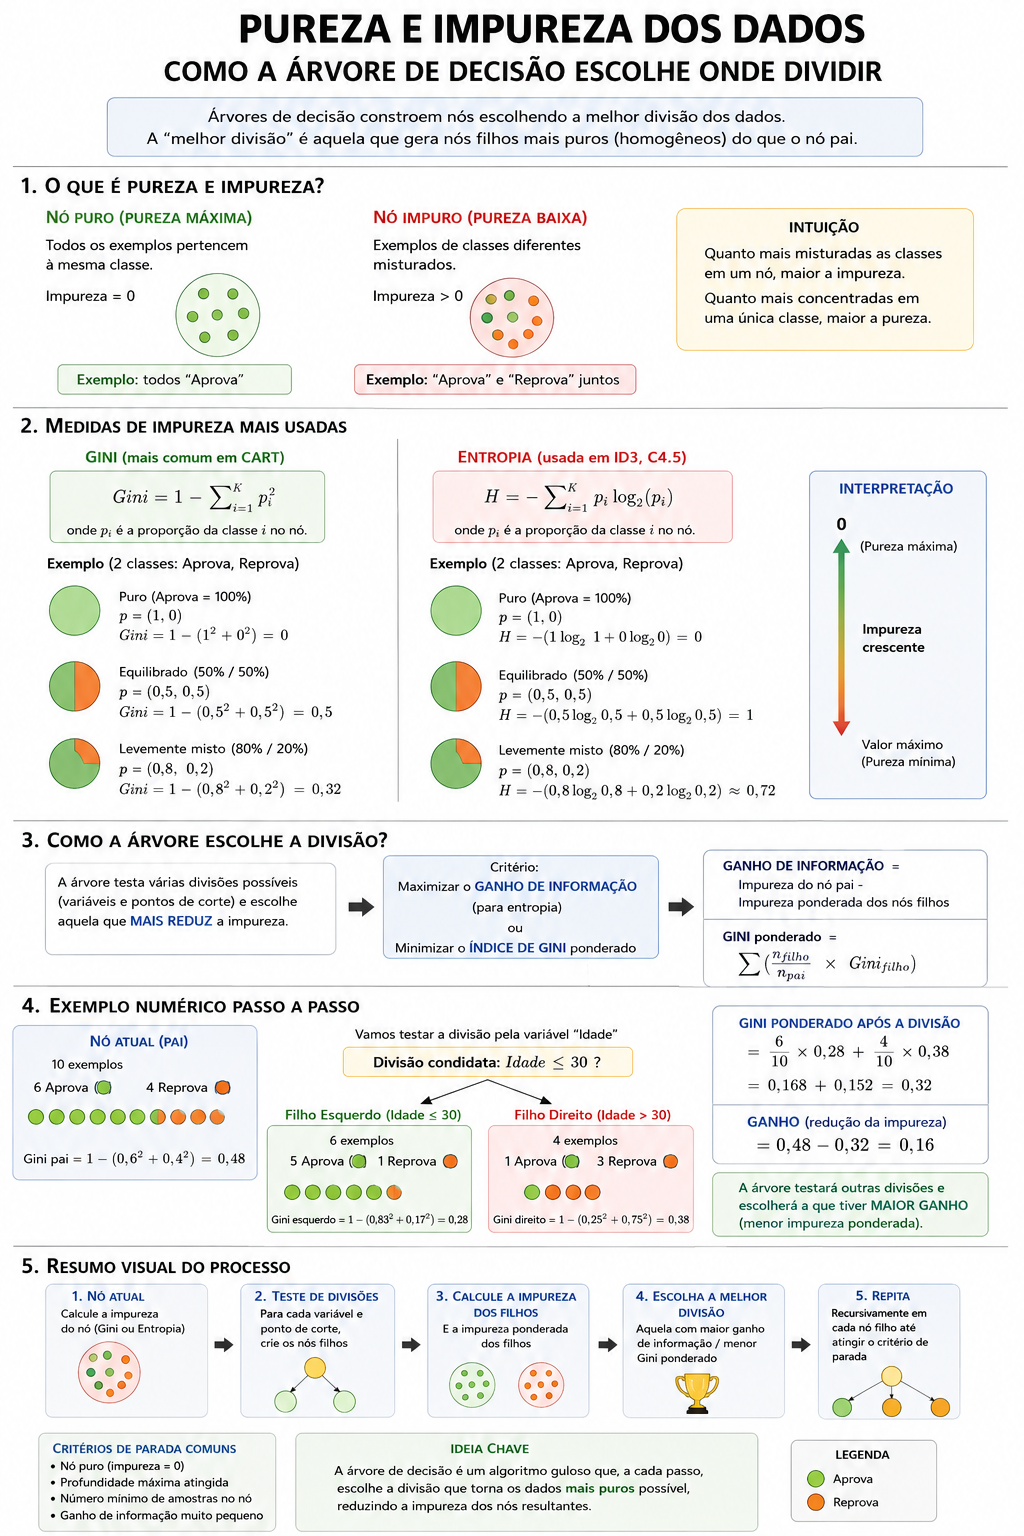

## Exemplo Classificação (Python)

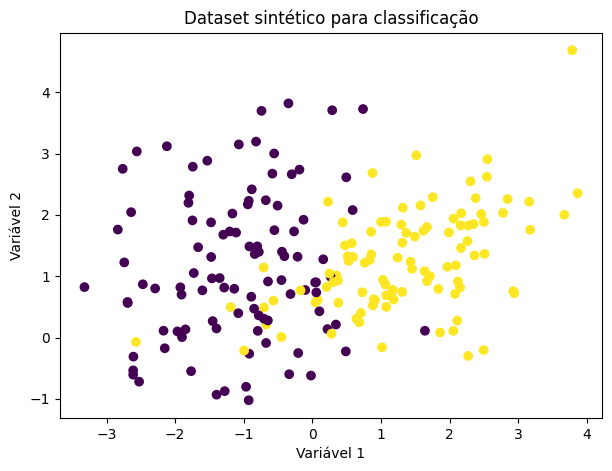

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.2,
    random_state=42
)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Variável 1")
plt.ylabel("Variável 2")
plt.title("Dataset sintético para classificação")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

modelo_clf = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)

modelo_clf.fit(X_train, y_train)

y_pred = modelo_clf.predict(X_test)

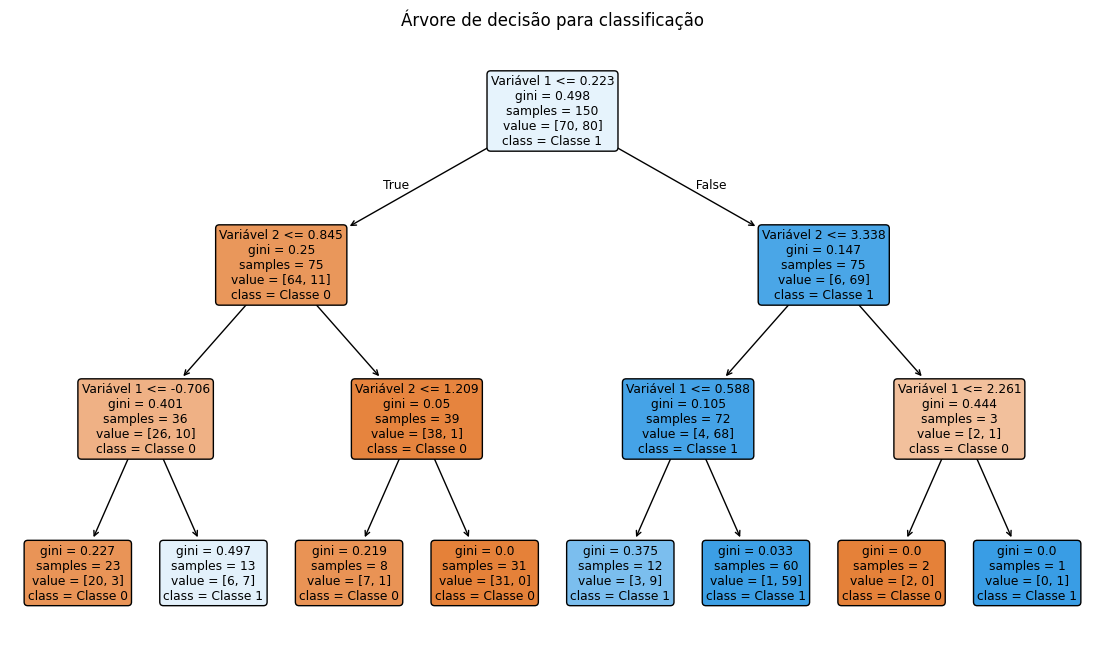

In [6]:
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 8))

plot_tree(
    modelo_clf,
    filled=True,
    feature_names=["Variável 1", "Variável 2"],
    class_names=["Classe 0", "Classe 1"],
    rounded=True
)

plt.title("Árvore de decisão para classificação")

plt.show()



## Fronteira de Decisão

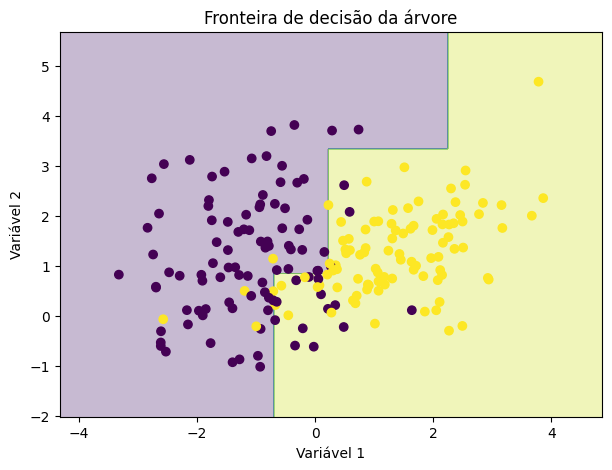

In [7]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.xlabel("Variável 1")
    plt.ylabel("Variável 2")
    plt.title("Fronteira de decisão da árvore")
    plt.show()

plot_decision_boundary(modelo_clf, X, y)

## Profundidade em Árvore de Decisão

Árvores muito profundas podem memorizar os dados de treinamento.

Isso é chamado de **overfitting**.

Sinais de overfitting:

- desempenho muito alto no treino;
- desempenho menor no teste;
- árvore muito grande;
- regras muito específicas.

Principais parâmetros para controlar o crescimento:

| Parâmetro | Função |
|---|---|
| `max_depth` | Limita a profundidade máxima |
| `min_samples_split` | Mínimo de amostras para dividir um nó |
| `min_samples_leaf` | Mínimo de amostras em uma folha |
| `criterion` | Critério de divisão |
| `ccp_alpha` | Parâmetro de poda |


## Árvore Profunda versus Árvore Rasa

In [8]:
modelo_raso = DecisionTreeClassifier(max_depth=2, random_state=42)
modelo_profundo = DecisionTreeClassifier(max_depth=None, random_state=42)

modelo_raso.fit(X_train, y_train)
modelo_profundo.fit(X_train, y_train)

print("Árvore rasa")
print("Acurácia treino:", modelo_raso.score(X_train, y_train))
print("Acurácia teste :", modelo_raso.score(X_test, y_test))

print("\nÁrvore profunda")
print("Acurácia treino:", modelo_profundo.score(X_train, y_train))
print("Acurácia teste :", modelo_profundo.score(X_test, y_test))

Árvore rasa
Acurácia treino: 0.8933333333333333
Acurácia teste : 0.94

Árvore profunda
Acurácia treino: 1.0
Acurácia teste : 0.88


## Regressão

Na regressão, a árvore não retorna uma classe.

Ela retorna um valor numérico.

Em cada folha, a previsão geralmente é a média dos valores de saída das amostras que chegaram naquela folha.

Exemplo:

```text
Valores na folha: [10, 12, 14]

Previsão = média = 12
```

## Critério de Divisão

Em regressão, a árvore tenta reduzir o erro numérico.

Um critério comum é o erro quadrático médio:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

A árvore procura divisões que reduzem o MSE.

## Exemplo em Python (sklearn)

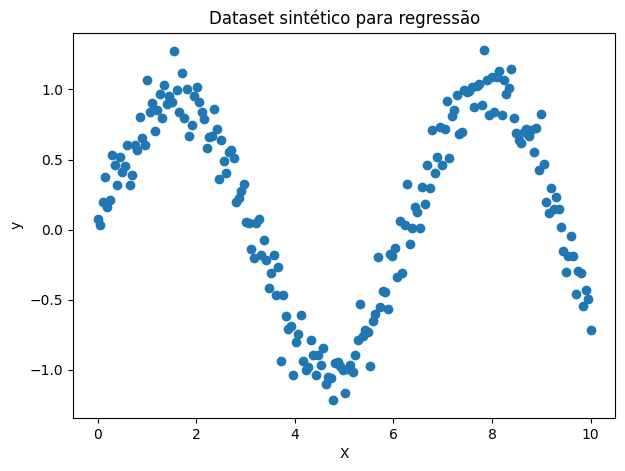

In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)

X_reg = np.linspace(0, 10, 200).reshape(-1, 1)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.15, size=200)

plt.figure(figsize=(7, 5))
plt.scatter(X_reg, y_reg)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Dataset sintético para regressão")
plt.show()

In [13]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

modelo_reg = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

modelo_reg.fit(X_train_reg, y_train_reg)

y_pred_reg = modelo_reg.predict(X_test_reg)

print("MAE :", mean_absolute_error(y_test_reg, y_pred_reg))
print("MSE :", mean_squared_error(y_test_reg, y_pred_reg))

MAE : 0.1630336482414627
MSE : 0.0465182710726084


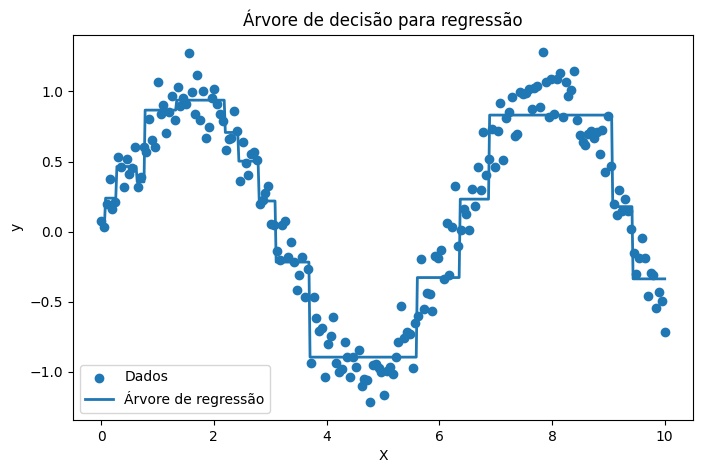

In [14]:
X_grid = np.linspace(0, 10, 500).reshape(-1, 1)
y_grid_pred = modelo_reg.predict(X_grid)

plt.figure(figsize=(8, 5))
plt.scatter(X_reg, y_reg, label="Dados")
plt.plot(X_grid, y_grid_pred, linewidth=2, label="Árvore de regressão")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Árvore de decisão para regressão")
plt.legend()
plt.show()

## Profundidade da Árvore na Regressão

* Uma árvore muito rasa pode sofrer underfitting.

* Uma árvore muito profunda pode sofrer overfitting.

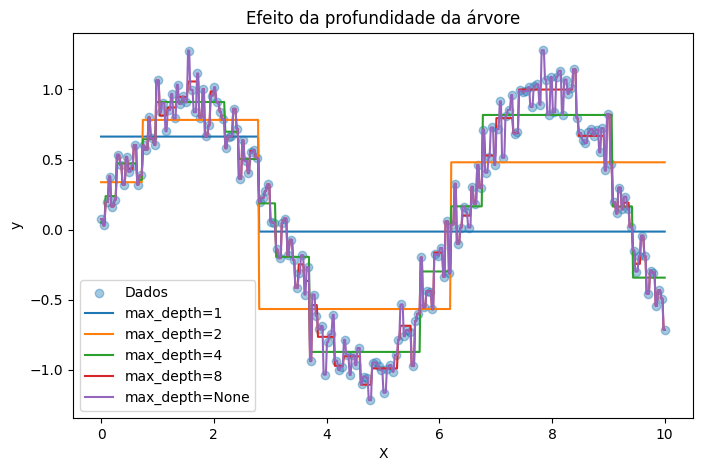

In [15]:
profundidades = [1, 2, 4, 8, None]

plt.figure(figsize=(8, 5))
plt.scatter(X_reg, y_reg, alpha=0.4, label="Dados")

for profundidade in profundidades:
    modelo = DecisionTreeRegressor(max_depth=profundidade, random_state=42)
    modelo.fit(X_reg, y_reg)
    y_pred_grid = modelo.predict(X_grid)
    label = f"max_depth={profundidade}"
    plt.plot(X_grid, y_pred_grid, label=label)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Efeito da profundidade da árvore")
plt.legend()
plt.show()

# Referências

* Mãos à Obra: aprendizado de máquina com scikit-learn, keras & tensorflow.

* Inteligência Artificial - uma abordagem de aprendizado de máquina.

# Créditos

* Imagens geradas pelo chatgpt.